In [1]:
import os
import multiprocessing as mp

def process_year(args):
    year, input_path, output_path, prefix = args
    os.system(f'cdo -setattribute,ch4@units="mgCH4/m2/d" -expr,"ch4=f_ch4_surf_flux_tot*16.04*1e3*86400" -selname,f_ch4_surf_flux_tot {input_path}/{prefix}_hist_{year}.nc {output_path}/net_methane_{year}_tmp1.nc')

def g1(input_path, output_path, area_path, prefix, yr_stt, yr_end):
    years = list(range(yr_stt, yr_end + 1))
    
    # Parallel processing of individual years
    with mp.Pool(processes=mp.cpu_count()) as pool:
        pool.map(process_year, [(year, input_path, output_path, prefix) for year in years])
    
    # Build the file list string for merging
    name = ' '.join([f"{output_path}net_methane_{year}_tmp1.nc" for year in years])
    
    os.system(f'cdo -O mergetime {name} {output_path}/net_methane_{yr_stt}_{yr_end}_tmp1.nc')
    os.system(f'cdo -O -monmean {output_path}/net_methane_{yr_stt}_{yr_end}_tmp1.nc {output_path}/net_methane_{yr_stt}_{yr_end}_tmp2.nc')
    os.system(f'cdo -O -yearmean {output_path}/net_methane_{yr_stt}_{yr_end}_tmp1.nc {output_path}/net_methane_{yr_stt}_{yr_end}_tmp3.nc')

    os.system(f'cdo -O -setattribute,ch4@units="gCH4/yr" -mulc,365 -divc,1e3 -mul {output_path}/net_methane_{yr_stt}_{yr_end}_tmp3.nc {area_path}Area_2p.nc {output_path}net_methane_{yr_stt}_{yr_end}_sum_tmp1.nc')
    os.system(f'cdo -O -setattribute,ch4@units="TgCH4/yr" -divc,1e12 -fldsum {output_path}net_methane_{yr_stt}_{yr_end}_sum_tmp1.nc {output_path}net_methane_{yr_stt}_{yr_end}_sum.nc')

prefix = 'g1_wetland_sat'
input_path = f'/share/home/dq076/data/cases/globe/{prefix}/history/'
output_path = f'/share/home/dq076/data/cases/globe/{prefix}/postdata/'
area_path = f'/share/home/dq076/data/Area/'
os.makedirs(output_path, exist_ok=True)
g1(input_path, output_path, area_path, prefix, 1995, 2000)

cdi  warning (cdf_check_variables): 5 dimensional variables are not supported, skipped variable f_alb!
cdi  warning (cdf_check_variables): 5 dimensional variables are not supported, skipped variable f_alb!
cdi  warning (cdf_check_variables): 5 dimensional variables are not supported, skipped variable f_alb!
cdi  warning (cdf_check_variables): 5 dimensional variables are not supported, skipped variable f_alb!
cdi  warning (cdf_check_variables): 5 dimensional variables are not supported, skipped variable f_alb!
cdi  warning (cdf_check_variables): 5 dimensional variables are not supported, skipped variable f_alb!


cdo(3) mul: Filling up stream2 >/share/home/dq076/data/Area/Area_2p.nc< by copying the first timestep.


In [2]:
%matplotlib inline

import os
import cmaps
import numpy as np
import xarray as xr
import pandas as pd
import netCDF4 as nc
import rioxarray as rxr
import geopandas as gpd
from pylab import rcParams
# import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.patches as patches
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

pd.set_option('display.max_columns', None)

params = {'font.family': 'Arial',
          'backend': 'ps',
          'axes.labelsize': 25,
          'grid.linewidth': 0.2,
          'font.size': 25,
          'legend.fontsize': 18,
          'legend.frameon': False,
          'xtick.labelsize': 30,
          'xtick.direction': 'out',
          'ytick.labelsize': 30,
          'ytick.direction': 'out',
          'legend.handlelength': 1,
          'legend.handleheight': 1,
          'savefig.bbox': 'tight',
          'axes.unicode_minus': False,
          "mathtext.default":"regular",
          'text.usetex': False}
rcParams.update(params)

def define_colormap(levels, cmap):
    """Define custom colormap and normalization."""
    # Generate colormap
    cmap = plt.get_cmap(cmap)
    color = cmap(np.linspace(0, 1, len(levels) - 1))
    cmap_custom = colors.ListedColormap(color)
    cmap_custom.set_under(cmap(0))
    cmap_custom.set_over(color[-1])
    norm = colors.BoundaryNorm(levels, cmap_custom.N)
    return cmap_custom, norm

def draw(path,name,level,cmap,region,norm):
    ds = xr.open_dataset(path).sel(lon=slice(region[0], region[1]), lat=slice(region[3], region[2]))
    data = ds['ch4'][1,:,:]
    print(data)
    # data = np.ma.masked_where(np.isnan(data), data)
    # data = np.flipud(data)
    
    fig = plt.figure(figsize=(12, 6), dpi=300)

    fig.subplots_adjust(left=0.05, right=0.98, 
                    bottom=0.14, top=0.95, hspace=0.25) 
        
    #Create a subgraph grid with 2 rows and 3 columns
    gs = GridSpec(2, 6)
    ax = fig.add_subplot(gs[:, :], projection=ccrs.PlateCarree())

    # Set drawing mode(note:region's lat from positive to negative)
    img = ax.imshow(data, cmap=cmap, extent=region, norm=norm)

    for spine in ax.spines.values():
        spine.set_edgecolor('black')  
        spine.set_linewidth(0)  

    ax.set_xlim(region[0], region[1])
    ax.set_ylim(region[2], region[3])

    # coastline = cfeature.NaturalEarthFeature('physical', 'coastline', '50m', edgecolor='0.6', facecolor='none')
    rivers = cfeature.NaturalEarthFeature('physical', 'rivers_lake_centerlines', '110m', edgecolor='0.6', facecolor='none')
    ax.add_feature(cfeature.LAND, facecolor='0.95')
    # ax.add_feature(coastline, linewidth=0.6)
    ax.add_feature(cfeature.LAKES, alpha=1, facecolor='white', edgecolor='white')
    ax.add_feature(rivers, linewidth=0.8)
    # ax.gridlines(draw_labels=False, linestyle=':', linewidth=0.7, color='grey', alpha=0.8)

    ax.add_feature(cfeature.COASTLINE)
    ax.set_extent(region)
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())

    # ax.grid(ls = "--", lw = 0.25, color = "#4E616C")

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linestyle='--', color='#4E616C')   
    gl.xlocator = ticker.FixedLocator(np.arange(-120, 181, 60)) 
    gl.ylocator = ticker.FixedLocator(np.arange(-60, 91, 30))    

    # From the bottom left corner x, y, width, height
    custom_ticks = [0, 10, 20, 30, 40]
    # cbar_ax = fig.add_axes([0.4, 0.14, 0.4, 0.03], frameon = False) 
    cbar_ax = fig.add_axes([0.1, 0.06, 0.8, 0.04], frameon = True) 
    cb = fig.colorbar(img, 
                    drawedges=True,
                    ticks=level, 
                    cax=cbar_ax, 
                    orientation='horizontal',
                    spacing='uniform')

    cb.ax.tick_params(labelsize=20)
    cb.ax.yaxis.set_tick_params(direction='out', width=1.5)
    # for label in cb.ax.get_xticklabels() + cb.ax.get_yticklabels():
    #     label.set_fontproperties(font_properties)
    cb.set_label(f'{name[3]}', fontsize=30, fontweight='bold')

    cb.outline.set_visible(True)
    cb.outline.set_edgecolor('#333333')
    cb.outline.set_linewidth(2)

    plt.tight_layout()
    plt.show()

<xarray.DataArray 'ch4' (lat: 75, lon: 180)> Size: 54kB
[13500 values with dtype=float32]
Coordinates:
    time     datetime64[ns] 8B 1996-07-01T12:00:00
  * lon      (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
  * lat      (lat) float32 300B 89.0 87.0 85.0 83.0 ... -53.0 -55.0 -57.0 -59.0
Attributes:
    units:         mgCH4/m2/d
    cell_methods:  time: mean


/tmp/ipykernel_276888/2892370374.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


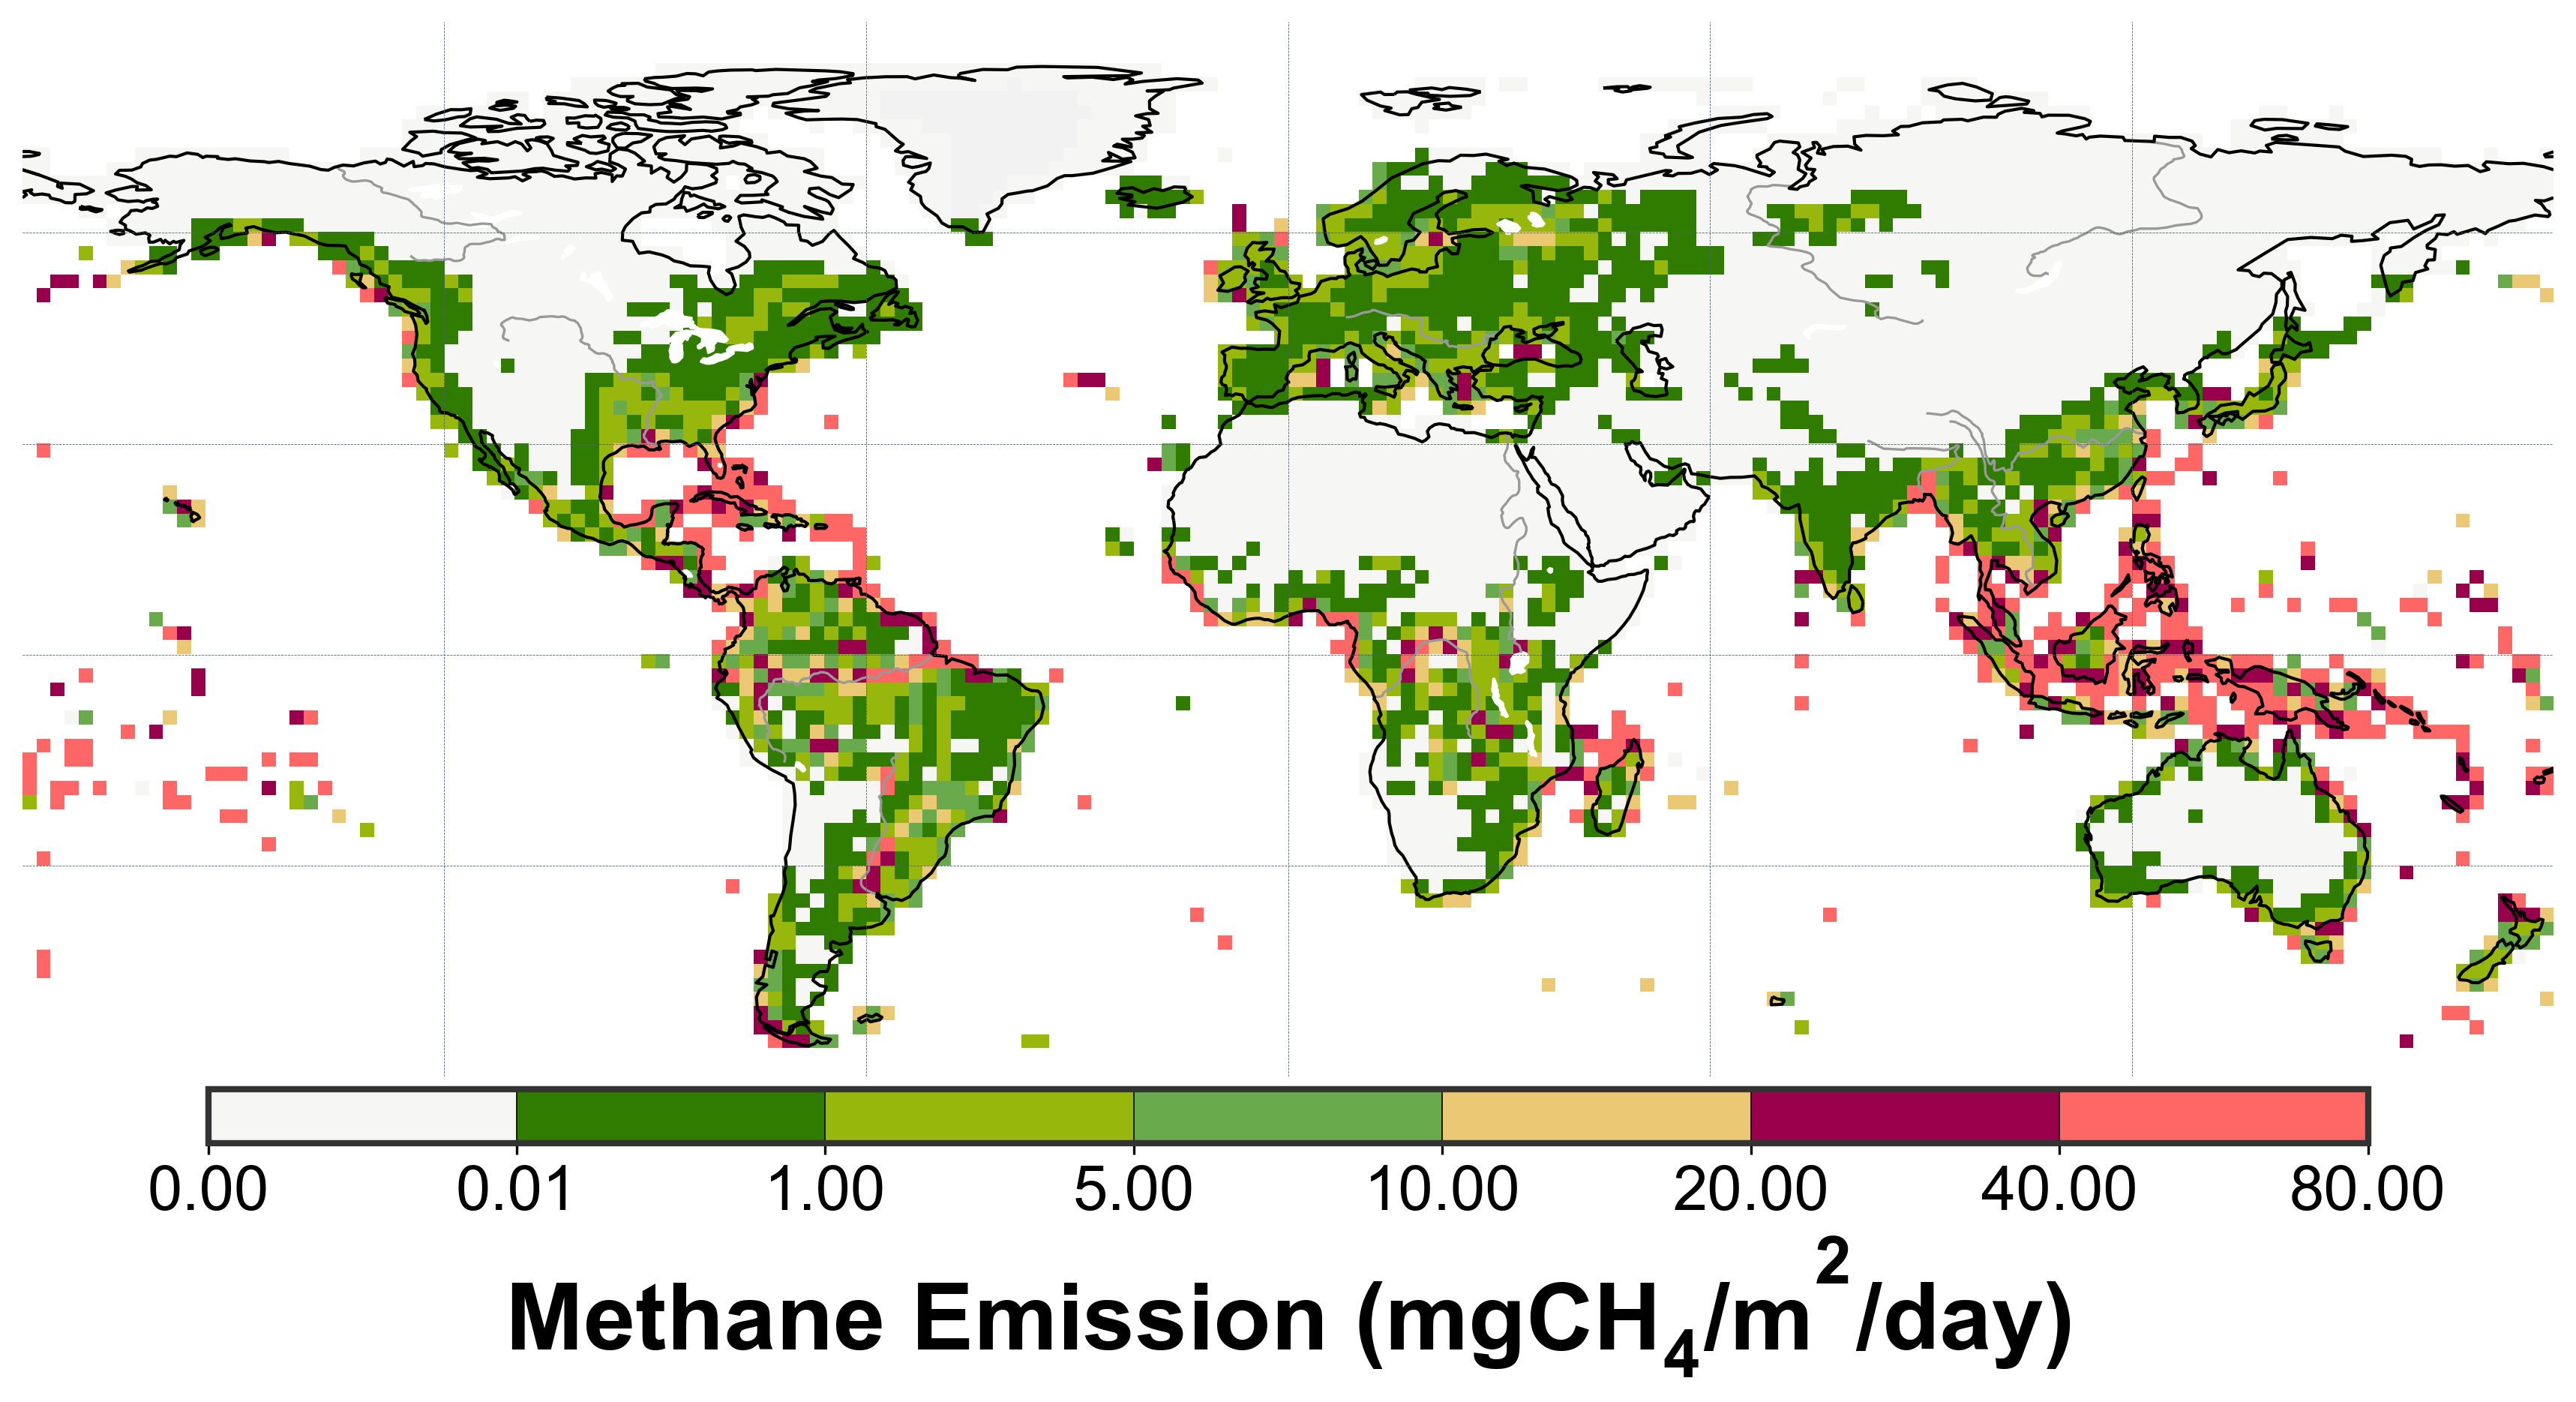

In [11]:
prefix='g1_wetland_sat'
yrstt = 1995
yrend = 2000
path = f'/share/home/dq076/data/cases/globe/{prefix}/postdata/net_methane_{yrstt}_{yrend}_tmp3.nc'

region = [-180,180,-60,90]
name = [f'Sbedrock', 'Sbedrock', 'Sbedrock', r"Methane Emission (mg$CH_{4}$/$m^{2}$/day)"]
level = [0, 0.01, 1, 5, 10, 20, 40, 80]
# cmap = cmaps.cmp_b2r
rgb_list = ['#f6f6f5','#2f7c00','#64a201','#97b70d',
                                '#69aa4c','#CCCC00','#ebc874','#99004C','#FF6666']
cmap = colors.ListedColormap(rgb_list)
cmap, norm = define_colormap(level, cmap)
draw(path,name,level,cmap,region,norm)